In [1]:
!pip install resampy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 39.1 MB/s eta 0:00:0000:0100:01


In [2]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import resampy

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import classification_report, accuracy_score
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers.schedules import ExponentialDecay

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten, Conv1D, MaxPooling1D, BatchNormalization
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import warnings
warnings.filterwarnings("ignore")

print("TensorFlow Version:", tf.__version__)

2026-03-28 14:33:06.137070: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774708386.347868      38 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774708386.412842      38 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


TensorFlow Version: 2.18.0


RAVDESS

In [3]:
all_features = []
all_labels = []

In [4]:
RAV = "/kaggle/input/ravdess-emotional-speech-audio/audio_speech_actors_01-24/"

EMO = "/kaggle/input/berlin-database-of-emotional-speech-emodb/wav"
# giữ intersection cuar 2 data 
TARGET_EMOTIONS = ["angry", "sad", "fear", "happy", "neutral", "disgust"]

SAMPLE_RATE = 22050
MAX_LEN_MFCC = 216 
N_MFCC = 40 

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.00001, verbose=1)
lr_schedule = ExponentialDecay(initial_learning_rate=0.001, decay_steps=5,decay_rate=0.95, staircase=True)

In [5]:
# 1. Hàm cho RAVDESS
def parse_ravdess_filename(filename):
    parts = filename.split('.')[0].split('-')
    
    if len(parts) < 3:
        return None
    
    emotion_code = int(parts[2])

    ravdess_emotion_map = {
        1: "neutral",
        2: "calm",
        3: "happy",
        4: "sad",
        5: "angry",
        6: "fear",
        7: "disgust",
        8: "surprised"
    }

    return ravdess_emotion_map.get(emotion_code, None)

# 2. Hàm cho EmoDB 
def parse_emodb_filename(filename):
    emotion_code = filename[5]

    emodb_emotion_map = {
        'W': "angry",     # Wut
        'L': "boredom",   # Langeweile
        'E': "disgust",   # Ekel
        'A': "fear",      # Angst
        'F': "happy",     # Freude
        'T': "sad",       # Trauer
        'N': "neutral"
    }

    return emodb_emotion_map.get(emotion_code, None)

In [6]:
def extract_aggregated_features(file_path, sample_rate=SAMPLE_RATE):
    """
    Trích xuất một vector đặc trưng 1D tổng hợp từ một file âm thanh.
    """
    try:
        audio, sr = librosa.load(file_path, sr=sample_rate, res_type='kaiser_fast')
        
        # Normalize audio
        if np.max(np.abs(audio)) > 0:
            audio = audio / np.max(np.abs(audio))
        
        # Trích xuất các đặc trưng
        mfccs = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=13)
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr)
        spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sr)
        
        # Tổng hợp bằng cách lấy trung bình
        mfccs_mean = np.mean(mfccs.T, axis=0)
        chroma_mean = np.mean(chroma.T, axis=0)
        spectral_contrast_mean = np.mean(spectral_contrast.T, axis=0)
        
        # Kết hợp thành một vector duy nhất
        combined_features = np.hstack([mfccs_mean, chroma_mean, spectral_contrast_mean])
        
        return combined_features
    except Exception as e:
        print(f"Lỗi xử lý file {file_path}: {e}")
        return None

In [7]:
# --- 1. Xử lý RAVDESS ---
print("Bắt đầu xử lý RAVDESS...")
for actor_folder in os.listdir(RAV):
    actor_path = os.path.join(RAV, actor_folder)
    if os.path.isdir(actor_path):
        for filename in os.listdir(actor_path):
            if filename.endswith('.wav'):
                label = parse_ravdess_filename(filename)
                if label in TARGET_EMOTIONS:
                    file_path = os.path.join(actor_path, filename)
                    features = extract_aggregated_features(file_path) 
                    if features is not None:
                        all_features.append(features)
                        all_labels.append(label)

print(f"Đã xử lý xong RAVDESS. Tổng số file: {len(all_features)}")

Bắt đầu xử lý RAVDESS...
Đã xử lý xong RAVDESS. Tổng số file: 1056


In [8]:
# --- 2. Xử lý EmoDB ---
print("\nBắt đầu xử lý EmoDB...")
for filename in os.listdir(EMO):
    if filename.endswith('.wav'):
        label = parse_emodb_filename(filename)
        if label in TARGET_EMOTIONS:
            file_path = os.path.join(EMO, filename)
            features = extract_aggregated_features(file_path)
            if features is not None:
                all_features.append(features)
                all_labels.append(label)

print(f"Đã xử lý xong EmoDB. Tổng số file sau khi gộp: {len(all_features)}")


Bắt đầu xử lý EmoDB...
Đã xử lý xong EmoDB. Tổng số file sau khi gộp: 1510


In [9]:
# 1. Chuyển đổi sang numpy array
X = np.array(all_features)
y = np.array(all_labels)

# 2. Mã hóa nhãn
le = LabelEncoder()
y_encoded = le.fit_transform(y)
y_categorical = to_categorical(y_encoded)
num_classes = len(le.classes_)

# 3. Chia dữ liệu
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42, stratify=y_categorical)

# 4. Chuẩn hóa đặc trưng 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"Số lớp cảm xúc: {num_classes}")
print(f"Kích thước tập huấn luyện: {X_train.shape}")
print(f"Kích thước tập kiểm tra: {X_test.shape}")



Số lớp cảm xúc: 6
Kích thước tập huấn luyện: (1208, 32)
Kích thước tập kiểm tra: (302, 32)


In [10]:
def evaluate_model(model, model_name, history, X_test, y_test, label_encoder, baseline_accuracy=None):
    """
    Hàm tự động đánh giá model, in ra các chỉ số quan trọng để điền vào bảng,
    và so sánh hiệu suất với model baseline.
    """
    print(f"\n\n--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: {model_name.upper()} ---")

    # 1. Accuracy (Training) và (Validation)
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    print(f"Accuracy (Training): {train_acc*100:.2f}%")
    print(f"Accuracy (Validation): {val_acc*100:.2f}%")

    # 2. Tính toán các chỉ số trên tập Test
    y_pred_probs = model.predict(X_test)
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    y_true_classes = np.argmax(y_test, axis=1)

    # 3. Accuracy (Test)
    test_acc = accuracy_score(y_true_classes, y_pred_classes)
    print(f"Accuracy (Test): {test_acc*100:.2f}%")

    # 4. Lấy Precision, Recall, F1-Score (Macro)
    report_dict = classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_, output_dict=True)
    precision_macro = report_dict['macro avg']['precision']
    recall_macro = report_dict['macro avg']['recall']
    f1_score_macro = report_dict['macro avg']['f1-score']
    
    print(f"Precision (Macro): {precision_macro:.4f}")
    print(f"Recall (Macro): {recall_macro:.4f}")
    print(f"F1-Score (Macro): {f1_score_macro:.4f}")

    # 5. So sánh với Baseline
    if baseline_accuracy is not None:
        print("-" * 30)
        improvement = test_acc - baseline_accuracy
        print(f"So sánh với Baseline Test Accuracy ({baseline_accuracy*100:.2f}%): {improvement*100:+.2f}%")
        print("-" * 30)

    # 6. In Classification Report 
    print(f"\nClassification Report chi tiết cho {model_name}:")
    print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))
    
    return test_acc

In [11]:
# 5. Xây dựng model baseline
def build_baseline_model(input_shape, num_classes):
    model = Sequential([
        # Input Layer 
        Dense(128, activation='relu', input_shape=input_shape),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model
    

# Khởi tạo và compile model
input_shape = (X_train.shape[1],)
model_baseline = build_baseline_model(input_shape, num_classes)

model_baseline.compile(optimizer='adam', 
                       loss='categorical_crossentropy', 
                       metrics=['accuracy'])

model_baseline.summary()



2026-03-28 14:36:17.989076: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,758 (57.65 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
history = model_baseline.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_split=0.2, 
    verbose=1
)

Epoch 1/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.1618 - loss: 1.7868 - val_accuracy: 0.3223 - val_loss: 1.6606
Epoch 2/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3826 - loss: 1.5686 - val_accuracy: 0.3430 - val_loss: 1.5418
Epoch 3/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4658 - loss: 1.4238 - val_accuracy: 0.3926 - val_loss: 1.4587
Epoch 4/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4929 - loss: 1.3090 - val_accuracy: 0.4298 - val_loss: 1.3764
Epoch 5/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5570 - loss: 1.2091 - val_accuracy: 0.4132 - val_loss: 1.3056
Epoch 6/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5597 - loss: 1.1478 - val_accuracy: 0.4628 - val_loss: 1.2468
Epoch 7/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6392 - loss: 1.0256 - val_accuracy: 0.4752 - val_loss: 1.2284
Epoch 8/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6746 - loss: 0.9478 - val_accuracy: 0.5124 - val_loss

In [13]:
baseline_test_acc = evaluate_model(
    model=model_baseline,
    model_name="Baseline Model",
    history=history,
    X_test=X_test,
    y_test=y_test,
    label_encoder=le
)



--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: BASELINE MODEL ---
Accuracy (Training): 96.69%
Accuracy (Validation): 65.29%
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy (Test): 61.26%
Precision (Macro): 0.6076
Recall (Macro): 0.6129
F1-Score (Macro): 0.6032

Classification Report chi tiết cho Baseline Model:
              precision    recall  f1-score   support

       angry       0.66      0.81      0.73        64
     disgust       0.57      0.53      0.55        47
        fear       0.58      0.56      0.57        52
       happy       0.62      0.40      0.48        53
     neutral       0.61      0.77      0.68        35
         sad       0.61      0.61      0.61        51

    accuracy                           0.61       302
   macro avg       0.61      0.61      0.60       302
weighted avg       0.61      0.61      0.60       302



xong phan 2

Phan 3

3.1.1 Dropout +Dense

In [14]:
def build_dropout_only_model(input_shape, num_classes):
    """
    Xây dựng model chỉ sử dụng Dense và Dropout
    """
    model = Sequential([
        # Input Layer & Dense Layer 1
        Dense(128, activation='relu', input_shape=input_shape),
        Dropout(0.3),

        # Dense Layer 2
        Dense(64, activation='relu'),
        Dropout(0.3),

        # Dense Layer 3
        Dense(32, activation='relu'),
        Dropout(0.2),
    
        # Output Layer (thêm vào để hoàn chỉnh model)
        Dense(num_classes, activation='softmax')
    ])
    return model

In [15]:
input_shape = (X_train.shape[1],)
num_classes = y_categorical.shape[1]
dropout_model = build_dropout_only_model(input_shape, num_classes)

dropout_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

print("--- KIẾN TRÚC MODEL MỚI (DROPOUT) ---")
dropout_model.summary()

--- KIẾN TRÚC MODEL MỚI (DROPOUT) ---


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,758 (57.65 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
print("\n--- Bắt đầu Huấn luyện Model Tối Ưu ---")
history_dropout = dropout_model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


--- Bắt đầu Huấn luyện Model Tối Ưu ---
Epoch 1/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.1868 - loss: 1.8682 - val_accuracy: 0.2521 - val_loss: 1.7242
Epoch 2/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2283 - loss: 1.7563 - val_accuracy: 0.2975 - val_loss: 1.6824
Epoch 3/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2708 - loss: 1.6766 - val_accuracy: 0.3264 - val_loss: 1.6154
Epoch 4/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3036 - loss: 1.6302 - val_accuracy: 0.3388 - val_loss: 1.5861
Epoch 5/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3545 - loss: 1.5723 - val_accuracy: 0.3802 - val_loss: 1.5287
Epoch 6/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3423 - loss: 1.5363 - val_accuracy: 0.4050 - val_loss: 1.4818
Epoch 7/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3770 - loss: 1.4928 - val_accuracy: 0.4091 - val_loss: 1.4525
Epoch 8/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4297 - loss:

In [17]:
dropout_test_acc = evaluate_model(
    model=dropout_model,
    model_name="Dropout-Only Model",
    history=history_dropout,
    X_test=X_test,
    y_test=y_test,
    label_encoder=le,
    baseline_accuracy=baseline_test_acc 
)



--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: DROPOUT-ONLY MODEL ---
Accuracy (Training): 64.60%
Accuracy (Validation): 57.02%
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy (Test): 55.30%
Precision (Macro): 0.5567
Recall (Macro): 0.5496
F1-Score (Macro): 0.5376
------------------------------
So sánh với Baseline Test Accuracy (61.26%): -5.96%
------------------------------

Classification Report chi tiết cho Dropout-Only Model:
              precision    recall  f1-score   support

       angry       0.71      0.72      0.71        64
     disgust       0.53      0.57      0.55        47
        fear       0.50      0.38      0.43        52
       happy       0.52      0.26      0.35        53
     neutral       0.62      0.57      0.60        35
         sad       0.46      0.78      0.58        51

    accuracy                           0.55       302
   macro avg       0.56      0.55      0.54       302
weighted avg       0.56      0.55      0.54       302



3.1.2 Batch

In [18]:
def build_batchnorm_only_model(input_shape, num_classes):
    """
    Xây dựng model chỉ sử dụng Dense và Batch Normalization.
    """
    model = Sequential([
        # Block 1
        Dense(128, activation='relu', input_shape=input_shape),
        BatchNormalization(),

        # Block 2
        Dense(64, activation='relu'),
        BatchNormalization(),

        # Block 3
        Dense(32, activation='relu'),
        BatchNormalization(),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model

In [19]:
batchnorm_model = build_batchnorm_only_model(input_shape, num_classes)
batchnorm_model.compile(optimizer='adam',
                        loss='categorical_crossentropy',
                        metrics=['accuracy'])

print("--- KIẾN TRÚC MODEL (BATCH NORMALIZATION) ---")
batchnorm_model.summary()

--- KIẾN TRÚC MODEL (BATCH NORMALIZATION) ---


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,654 (61.15 KB)

 Trainable params: 15,206 (59.40 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
print("\n--- Bắt đầu Huấn luyện Model (Batch Normalization) ---")
history_batchnorm = batchnorm_model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


--- Bắt đầu Huấn luyện Model (Batch Normalization) ---
Epoch 1/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.2417 - loss: 2.1218 - val_accuracy: 0.3306 - val_loss: 1.6594
Epoch 2/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4529 - loss: 1.4506 - val_accuracy: 0.3512 - val_loss: 1.5923
Epoch 3/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5061 - loss: 1.2873 - val_accuracy: 0.4132 - val_loss: 1.5247
Epoch 4/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5815 - loss: 1.1406 - val_accuracy: 0.4463 - val_loss: 1.4702
Epoch 5/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6308 - loss: 1.0640 - val_accuracy: 0.4504 - val_loss: 1.4117
Epoch 6/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6473 - loss: 1.0261 - val_accuracy: 0.4917 - val_loss: 1.3312
Epoch 7/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7056 - loss: 0.8891 - val_accuracy: 0.5083 - val_loss: 1.2683
Epoch 8/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy:

In [21]:
batchnorm_test_acc = evaluate_model(
    model=batchnorm_model,
    model_name="BatchNorm-Only Model",
    history=history_batchnorm,
    X_test=X_test,
    y_test=y_test,
    label_encoder=le,
    baseline_accuracy=baseline_test_acc
)



--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: BATCHNORM-ONLY MODEL ---
Accuracy (Training): 92.03%
Accuracy (Validation): 64.88%
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
Accuracy (Test): 56.62%
Precision (Macro): 0.5607
Recall (Macro): 0.5644
F1-Score (Macro): 0.5590
------------------------------
So sánh với Baseline Test Accuracy (61.26%): -4.64%
------------------------------

Classification Report chi tiết cho BatchNorm-Only Model:
              precision    recall  f1-score   support

       angry       0.68      0.78      0.73        64
     disgust       0.59      0.51      0.55        47
        fear       0.39      0.37      0.38        52
       happy       0.53      0.40      0.45        53
     neutral       0.65      0.69      0.67        35
         sad       0.53      0.65      0.58        51

    accuracy                           0.57       302
   macro avg       0.56      0.56      0.56       302
weighted avg       0.56      0.57      0.56       302



3.1.4 L2

In [22]:
def build_l2_only_model(input_shape, num_classes, l2_rate=0.0001):
    """
    Xây dựng model baseline nhưng thêm L2 Regularization vào mỗi lớp Dense.
    """
    model = Sequential([
        # kernel_regularizer=l2(l2_rate) sẽ thêm L2 penalty vào trọng số của lớp này
        Dense(128, activation='relu', input_shape=input_shape, kernel_regularizer=l2(l2_rate)),
        Dense(64, activation='relu', kernel_regularizer=l2(l2_rate)),
        Dense(32, activation='relu', kernel_regularizer=l2(l2_rate)),

        # Lớp Output 
        Dense(num_classes, activation='softmax')
    ])
    return model

# 2. Khởi tạo và compile model
# Sử dụng giá trị λ = 0.0001 
l2_model = build_l2_only_model(input_shape, num_classes, l2_rate=0.0001)
l2_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])

print("--- KIẾN TRÚC MODEL (L2 REGULARIZATION) ---")
l2_model.summary()

--- KIẾN TRÚC MODEL (L2 REGULARIZATION) ---


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,758 (57.65 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

In [23]:
print("\n--- Bắt đầu Huấn luyện Model ( L2 Regularization) ---")
history_l2 = l2_model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


--- Bắt đầu Huấn luyện Model ( L2 Regularization) ---
Epoch 1/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.2865 - loss: 1.7630 - val_accuracy: 0.3512 - val_loss: 1.6594
Epoch 2/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3750 - loss: 1.5644 - val_accuracy: 0.3636 - val_loss: 1.5528
Epoch 3/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5118 - loss: 1.3988 - val_accuracy: 0.3884 - val_loss: 1.4503
Epoch 4/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5728 - loss: 1.2576 - val_accuracy: 0.4504 - val_loss: 1.3751
Epoch 5/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5914 - loss: 1.1657 - val_accuracy: 0.4876 - val_loss: 1.2957
Epoch 6/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5887 - loss: 1.1306 - val_accuracy: 0.4835 - val_loss: 1.2739
Epoch 7/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6377 - loss: 1.0189 - val_accuracy: 0.4917 - val_loss: 1.2192
Epoch 8/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 

In [24]:
l2_test_acc = evaluate_model(
    model=l2_model,
    model_name="L2-Only Model",
    history=history_l2,
    X_test=X_test,
    y_test=y_test,
    label_encoder=le,
    baseline_accuracy=baseline_test_acc
)




--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: L2-ONLY MODEL ---
Accuracy (Training): 95.55%
Accuracy (Validation): 62.40%
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
Accuracy (Test): 60.93%
Precision (Macro): 0.6090
Recall (Macro): 0.6140
F1-Score (Macro): 0.6031
------------------------------
So sánh với Baseline Test Accuracy (61.26%): -0.33%
------------------------------

Classification Report chi tiết cho L2-Only Model:
              precision    recall  f1-score   support

       angry       0.71      0.80      0.75        64
     disgust       0.51      0.55      0.53        47
        fear       0.61      0.44      0.51        52
       happy       0.60      0.40      0.48        53
     neutral       0.71      0.83      0.76        35
         sad       0.52      0.67      0.59        51

    accuracy                           0.61       302
   macro avg       0.61      0.61      0.60       302
weighted avg       0.61      0.61      0.60       302



3.2.1 Pitch Shifting

In [25]:
def add_noise(audio, noise_factor=0.005):
    """Thêm nhiễu background vào âm thanh gốc."""
    noise = np.random.randn(len(audio))
    augmented_audio = audio + noise_factor * noise
    augmented_audio = augmented_audio.astype(type(audio[0]))
    return augmented_audio

def pitch_shift(audio, sample_rate, n_steps=2):
    """Thay đổi tần số cơ bản của âm thanh mà không thay đổi tốc độ."""
    return librosa.effects.pitch_shift(y=audio, sr=sample_rate, n_steps=n_steps)

def time_stretching(audio, rate=0.9):
    """Thay đổi tốc độ phát lại của âm thanh (thay đổi độ dài file nhưng giữ pitch)."""
    return librosa.effects.time_stretch(y=audio, rate=rate)

def extract_features_from_audio(audio, sample_rate):
    mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=13)
    chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
    spectral_contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
    mfccs_mean = np.mean(mfccs.T, axis=0)
    chroma_mean = np.mean(chroma.T, axis=0)
    spectral_contrast_mean = np.mean(spectral_contrast.T, axis=0)
    return np.hstack([mfccs_mean, chroma_mean, spectral_contrast_mean])

augmented_features = []
augmented_labels = []


In [26]:
print("Bắt đầu thu thập đường dẫn của tất cả các file âm thanh...")
all_files = []
for actor_folder in os.listdir(RAV):
    actor_path = os.path.join(RAV, actor_folder)
    if os.path.isdir(actor_path):
        for filename in os.listdir(actor_path):
            if filename.endswith('.wav'):
                label = parse_ravdess_filename(filename)
                if label in TARGET_EMOTIONS:
                    all_files.append((os.path.join(actor_path, filename), label))
"""                  
for filename in os.listdir(EMO):
    if filename.endswith('.wav'):
        label = parse_emodb_filename(filename)
        if label in TARGET_EMOTIONS:
            all_files.append((os.path.join(EMO, filename), label))
            """  
print(f"Thu thập hoàn tất. Tổng số file gốc: {len(all_files)}")


Bắt đầu thu thập đường dẫn của tất cả các file âm thanh...
Thu thập hoàn tất. Tổng số file gốc: 1056


In [27]:
print(f"Tổng số file gốc: {len(all_files)}")
print("Bắt đầu quá trình tạo dữ liệu 3x (Original + Noise + Pitch)...")

for file_path, label in all_files:
    try:
        audio, sr = librosa.load(file_path, sr=SAMPLE_RATE, res_type='kaiser_fast')
        
        # 1. Mẫu gốc
        original_features = extract_features_from_audio(audio, sr)
        augmented_features.append(original_features)
        augmented_labels.append(label)

        # 2. Mẫu thêm nhiễu
        noisy_audio = add_noise(audio)
        noisy_features = extract_features_from_audio(noisy_audio, sr)
        augmented_features.append(noisy_features)
        augmented_labels.append(label)
        
        # 3. Mẫu thay đổi cao độ 
        random_pitch_steps = np.random.randint(-3, 4)
        pitched_audio = pitch_shift(audio, sr, n_steps=random_pitch_steps)
        pitched_features = extract_features_from_audio(pitched_audio, sr)
        augmented_features.append(pitched_features)
        augmented_labels.append(label)

    except Exception as e:
        print(f"Lỗi xử lý file {file_path}: {e}")

print(f"\nHoàn tất! Tổng số mẫu sau khi tăng cường: {len(augmented_features)}")

X_aug = np.array(augmented_features)
y_aug = np.array(augmented_labels)

y_aug_encoded = le.transform(y_aug) 
y_aug_categorical = to_categorical(y_aug_encoded)

X_train_aug, X_test_aug, y_train_aug, y_test_aug = train_test_split(
    X_aug, y_aug_categorical, test_size=0.2, random_state=42, stratify=y_aug_categorical
)

scaler_aug = StandardScaler()
X_train_aug = scaler_aug.fit_transform(X_train_aug)
X_test_aug = scaler_aug.transform(X_test_aug)

print("Dữ liệu tăng cường đã sẵn sàng để huấn luyện!")
print("Kích thước tập huấn luyện mới:", X_train_aug.shape)
print("Kích thước tập kiểm tra mới:", X_test_aug.shape)

Tổng số file gốc: 1056
Bắt đầu quá trình tạo dữ liệu 3x (Original + Noise + Pitch)...

Hoàn tất! Tổng số mẫu sau khi tăng cường: 3168
Dữ liệu tăng cường đã sẵn sàng để huấn luyện!
Kích thước tập huấn luyện mới: (2534, 32)
Kích thước tập kiểm tra mới: (634, 32)


In [28]:
data_aug_model = build_baseline_model(input_shape, num_classes)

data_aug_model.compile(optimizer='adam',
                       loss='categorical_crossentropy',
                       metrics=['accuracy'])

print("--- KIẾN TRÚC MODEL (DATA AUG) ---")
data_aug_model.summary()

--- KIẾN TRÚC MODEL (DATA AUG) ---


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,758 (57.65 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

In [29]:
print("Bắt đầu huấn luyện model trên dữ liệu 3x...")
history_aug = data_aug_model.fit(
    X_train_aug, y_train_aug,
    epochs=110,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Bắt đầu huấn luyện model trên dữ liệu 3x...
Epoch 1/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.2197 - loss: 1.7593 - val_accuracy: 0.3254 - val_loss: 1.5998
Epoch 2/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3650 - loss: 1.5544 - val_accuracy: 0.3550 - val_loss: 1.5028
Epoch 3/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4276 - loss: 1.4267 - val_accuracy: 0.4339 - val_loss: 1.4091
Epoch 4/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4789 - loss: 1.2934 - val_accuracy: 0.4615 - val_loss: 1.3468
Epoch 5/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5000 - loss: 1.2448 - val_accuracy: 0.4655 - val_loss: 1.3188
Epoch 6/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5268 - loss: 1.1706 - val_accuracy: 0.4734 - val_loss: 1.2733
Epoch 7/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5838 - loss: 1.0800 - val_accuracy: 0.5286 - val_loss: 1.2332
Epoch 8/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.59

In [30]:
# 4. Đánh giá model và so sánh với baseline gốc
data_aug_test_acc = evaluate_model(
    model=data_aug_model,
    model_name="Data-Augmentation Model",
    history=history_aug,
    X_test=X_test_aug, 
    y_test=y_test_aug, 
    label_encoder=le,
    baseline_accuracy=baseline_test_acc
)



--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: DATA-AUGMENTATION MODEL ---
Accuracy (Training): 97.34%
Accuracy (Validation): 62.52%
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Accuracy (Test): 59.46%
Precision (Macro): 0.6016
Recall (Macro): 0.6039
F1-Score (Macro): 0.6003
------------------------------
So sánh với Baseline Test Accuracy (61.26%): -1.79%
------------------------------

Classification Report chi tiết cho Data-Augmentation Model:
              precision    recall  f1-score   support

       angry       0.72      0.65      0.68       115
     disgust       0.55      0.60      0.58       116
        fear       0.54      0.63      0.58       115
       happy       0.57      0.45      0.50       115
     neutral       0.64      0.71      0.67        58
         sad       0.59      0.58      0.59       115

    accuracy                           0.59       634
   macro avg       0.60      0.60      0.60       634
weighted avg       0.60      0.59      0.59       634



3.3.1 LR scheduling ( reducelr early stop  exponential decay

In [31]:
exp_decay_model = build_baseline_model(input_shape, num_classes)

exp_decay_model.compile(optimizer='adam', 
                        loss='categorical_crossentropy', 
                        metrics=['accuracy'])

print("--- KIẾN TRÚC MODEL CHO LR SCHEDULE (DÙNG REDUCELR) ---")
exp_decay_model.summary()

--- KIẾN TRÚC MODEL CHO LR SCHEDULE (DÙNG REDUCELR) ---


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,758 (57.65 KB)

 Trainable params: 14,758 (57.65 KB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history_reduce_lr = exp_decay_model.fit(
    X_train, y_train,
    epochs=35,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

Epoch 1/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.2361 - loss: 1.7444 - val_accuracy: 0.3182 - val_loss: 1.6102 - learning_rate: 0.0010
Epoch 2/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3743 - loss: 1.5292 - val_accuracy: 0.4008 - val_loss: 1.4899 - learning_rate: 0.0010
Epoch 3/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4763 - loss: 1.3975 - val_accuracy: 0.4545 - val_loss: 1.3965 - learning_rate: 0.0010
Epoch 4/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5243 - loss: 1.2522 - val_accuracy: 0.4463 - val_loss: 1.3377 - learning_rate: 0.0010
Epoch 5/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5570 - loss: 1.1907 - val_accuracy: 0.5000 - val_loss: 1.2485 - learning_rate: 0.0010
Epoch 6/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6046 - loss: 1.1034 - val_accuracy: 0.5083 - val_loss: 1.2546 - learning_rate: 0.0010
Epoch 7/35
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6136 - loss: 1.0500 - val_accuracy:

In [33]:
lr_schedule_test_acc = evaluate_model(
    model=exp_decay_model,
    model_name="LR-Schedule Model (ReduceLR)",
    history=history_reduce_lr,
    X_test=X_test,
    y_test=y_test,
    label_encoder=le,
    baseline_accuracy=baseline_test_acc
)



--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: LR-SCHEDULE MODEL (REDUCELR) ---
Accuracy (Training): 96.58%
Accuracy (Validation): 64.05%
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
Accuracy (Test): 58.61%
Precision (Macro): 0.5842
Recall (Macro): 0.5849
F1-Score (Macro): 0.5819
------------------------------
So sánh với Baseline Test Accuracy (61.26%): -2.65%
------------------------------

Classification Report chi tiết cho LR-Schedule Model (ReduceLR):
              precision    recall  f1-score   support

       angry       0.76      0.75      0.76        64
     disgust       0.43      0.55      0.49        47
        fear       0.54      0.50      0.52        52
       happy       0.58      0.47      0.52        53
     neutral       0.62      0.69      0.65        35
         sad       0.57      0.55      0.56        51

    accuracy                           0.59       302
   macro avg       0.58      0.58      0.58       302
weighted avg       0.59      0.59      0.59       302



In [34]:
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.models import Sequential

def build_optimal_model(input_shape, num_classes, l2_rate=0.0001):
    """
    Xây dựng model tối ưu kết hợp các kỹ thuậtt:
    - Dense layers
    - Batch Normalization (sau Dense, trước Dropout)
    - L2 Regularization (trong Dense)
    - Dropout
    """
    model = Sequential([
        # Block 1
        Dense(128, activation='relu', input_shape=input_shape, kernel_regularizer=l2(l2_rate)),
        BatchNormalization(),
        Dropout(0.3),

        # Block 2
        Dense(64, activation='relu', kernel_regularizer=l2(l2_rate)),
        BatchNormalization(),
        Dropout(0.3),

        # Block 3
        Dense(32, activation='relu', kernel_regularizer=l2(l2_rate)),
        BatchNormalization(),
        Dropout(0.2),

        # Output Layer
        Dense(num_classes, activation='softmax')
    ])
    return model

In [35]:
# Khởi tạo model với input_shape từ dữ liệu augmented
input_shape_aug = (X_train_aug.shape[1],)
optimal_model = build_optimal_model(input_shape_aug, num_classes)

# Compile model
optimal_model.compile(optimizer='adam',
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

print("--- KIẾN TRÚC MODEL TỐI ƯU (KẾT HỢP TẤT CẢ) ---")
optimal_model.summary()

--- KIẾN TRÚC MODEL TỐI ƯU (KẾT HỢP TẤT CẢ) ---


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_24 (Dense)                │ (None, 128)            │         4,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,654 (61.15 KB)

 Trainable params: 15,206 (59.40 KB)

 Non-trainable params: 448 (1.75 KB)

In [36]:
print("\n--- Bắt đầu Huấn luyện Model Tối Ưu ---")
history_optimal = optimal_model.fit(
    X_train_aug, y_train_aug,
    epochs=110,  
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr], 
    verbose=1
)


--- Bắt đầu Huấn luyện Model Tối Ưu ---
Epoch 1/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.1711 - loss: 2.3900 - val_accuracy: 0.2919 - val_loss: 1.7211 - learning_rate: 0.0010
Epoch 2/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2577 - loss: 1.9057 - val_accuracy: 0.3491 - val_loss: 1.6407 - learning_rate: 0.0010
Epoch 3/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2900 - loss: 1.7773 - val_accuracy: 0.3925 - val_loss: 1.5732 - learning_rate: 0.0010
Epoch 4/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2990 - loss: 1.7158 - val_accuracy: 0.3787 - val_loss: 1.5227 - learning_rate: 0.0010
Epoch 5/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3398 - loss: 1.6250 - val_accuracy: 0.4043 - val_loss: 1.4693 - learning_rate: 0.0010
Epoch 6/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3660 - loss: 1.5842 - val_accuracy: 0.4379 - val_loss: 1.4325 - learning_rate: 0.0010
Epoch 7/110
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step -

In [37]:
# Đánh giá model trên tập test của dữ liệu augmented
optimal_model_test_acc = evaluate_model(
    model=optimal_model,
    model_name="Optimal Combined Model",
    history=history_optimal,
    X_test=X_test_aug,  
    y_test=y_test_aug, 
    label_encoder=le,
    baseline_accuracy=baseline_test_acc 
)



--- KẾT QUẢ ĐÁNH GIÁ CHO MODEL: OPTIMAL COMBINED MODEL ---
Accuracy (Training): 68.23%
Accuracy (Validation): 62.92%
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy (Test): 61.51%
Precision (Macro): 0.6183
Recall (Macro): 0.6099
F1-Score (Macro): 0.6123
------------------------------
So sánh với Baseline Test Accuracy (61.26%): +0.26%
------------------------------

Classification Report chi tiết cho Optimal Combined Model:
              precision    recall  f1-score   support

       angry       0.75      0.69      0.72       115
     disgust       0.56      0.64      0.60       116
        fear       0.62      0.56      0.59       115
       happy       0.55      0.53      0.54       115
     neutral       0.62      0.55      0.58        58
         sad       0.60      0.70      0.65       115

    accuracy                           0.62       634
   macro avg       0.62      0.61      0.61       634
weighted avg       0.62      0.62      0.62       634



In [38]:
from scipy.stats import mode 

In [39]:
ensemble_models = []
ensemble_histories = [] 
num_models_to_train = 5

print(f"--- BẮT ĐẦU HUẤN LUYỆN {num_models_to_train} MODELS CHO ENSEMBLE ---")

for i in range(num_models_to_train):
    print(f"\\n--- Training Model {i+1}/{num_models_to_train} ---")
    
    # Xây dựng model từ kiến trúc tối ưu
    input_shape_aug = (X_train_aug.shape[1],)
    model_instance = build_optimal_model(input_shape_aug, num_classes)
    
    # Compile model
    model_instance.compile(optimizer='adam',
                           loss='categorical_crossentropy',
                           metrics=['accuracy'])
    
    # Huấn luyện model và LƯU history lại
    history_instance = model_instance.fit(X_train_aug, y_train_aug,
                                          epochs=200,
                                          batch_size=32,
                                          validation_split=0.2,
                                          callbacks=[early_stopping, reduce_lr],
                                          verbose=0) 
    
    # Lưu model và history đã huấn luyện vào danh sách
    ensemble_models.append(model_instance)
    ensemble_histories.append(history_instance) # <-- THÊM MỚI
    print(f"--- Hoàn thành Model {i+1}/{num_models_to_train} ---")

print("\\n--- ĐÃ HUẤN LUYỆN XONG TẤT CẢ MODELS CHO ENSEMBLE ---")

--- BẮT ĐẦU HUẤN LUYỆN 5 MODELS CHO ENSEMBLE ---
\n--- Training Model 1/5 ---

Epoch 74: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 95: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 107: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 112: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
Epoch 112: early stopping
Restoring model weights from the end of the best epoch: 102.
--- Hoàn thành Model 1/5 ---
\n--- Training Model 2/5 ---

Epoch 45: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 62: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 83: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 94: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 99: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.
Epoch 99: early stopping
Restoring model weights from the end of the best e

In [40]:
print("\\n\\n--- KẾT QUẢ ĐÁNH GIÁ CHO ENSEMBLE MODEL (VOTING) ---")

# 1. Tính toán Training & Validation Accuracy trung bình từ các history
avg_train_acc = np.mean([h.history['accuracy'][-1] for h in ensemble_histories])
avg_val_acc = np.mean([h.history['val_accuracy'][-1] for h in ensemble_histories])

print(f"Accuracy (Training - Avg): {avg_train_acc*100:.2f}%")
print(f"Accuracy (Validation - Avg): {avg_val_acc*100:.2f}%")

# 2. Lấy dự đoán từ mỗi model và thực hiện voting 
all_predictions = []
for model in ensemble_models:
    y_pred_probs = model.predict(X_test_aug, verbose=0) 
    y_pred_classes = np.argmax(y_pred_probs, axis=1)
    all_predictions.append(y_pred_classes)

predictions_array = np.array(all_predictions)
ensemble_predictions, _ = mode(predictions_array, axis=0)

y_true_classes_aug = np.argmax(y_test_aug, axis=1)

# 3. Tính toán các chỉ số trên tập Test
# Accuracy
ensemble_accuracy = accuracy_score(y_true_classes_aug, ensemble_predictions)
print(f"Accuracy (Test): {ensemble_accuracy*100:.2f}%")

# Lấy Precision, Recall, F1-Score (Macro)
report_dict = classification_report(y_true_classes_aug, ensemble_predictions, target_names=le.classes_, output_dict=True)
precision_macro = report_dict['macro avg']['precision']
recall_macro = report_dict['macro avg']['recall']
f1_score_macro = report_dict['macro avg']['f1-score']

print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro): {recall_macro:.4f}")
print(f"F1-Score (Macro): {f1_score_macro:.4f}")

# So sánh với Baseline
print("-" * 30)
improvement = ensemble_accuracy - baseline_test_acc
print(f"So sánh với Baseline Test Accuracy ({baseline_test_acc*100:.2f}%): {improvement*100:+.2f}%")
print("-" * 30)

# In Classification Report chi tiết
print(f"\\nClassification Report chi tiết cho Ensemble Model:")
print(classification_report(y_true_classes_aug, ensemble_predictions, target_names=le.classes_))

\n\n--- KẾT QUẢ ĐÁNH GIÁ CHO ENSEMBLE MODEL (VOTING) ---
Accuracy (Training - Avg): 67.98%
Accuracy (Validation - Avg): 62.76%
Accuracy (Test): 62.30%
Precision (Macro): 0.6256
Recall (Macro): 0.6199
F1-Score (Macro): 0.6213
------------------------------
So sánh với Baseline Test Accuracy (61.26%): +1.04%
------------------------------
\nClassification Report chi tiết cho Ensemble Model:
              precision    recall  f1-score   support

       angry       0.73      0.70      0.71       115
     disgust       0.56      0.67      0.61       116
        fear       0.63      0.57      0.60       115
       happy       0.58      0.54      0.56       115
     neutral       0.62      0.59      0.60        58
         sad       0.63      0.65      0.64       115

    accuracy                           0.62       634
   macro avg       0.63      0.62      0.62       634
weighted avg       0.63      0.62      0.62       634



10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


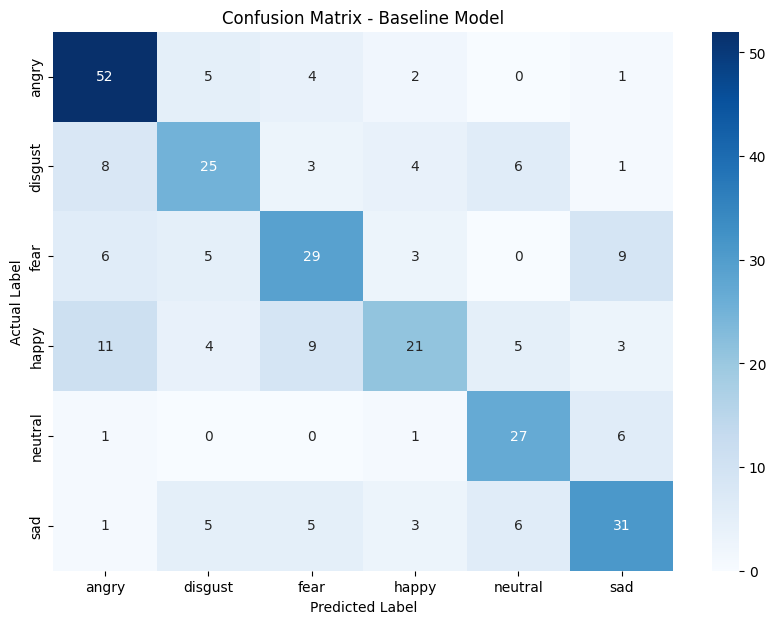

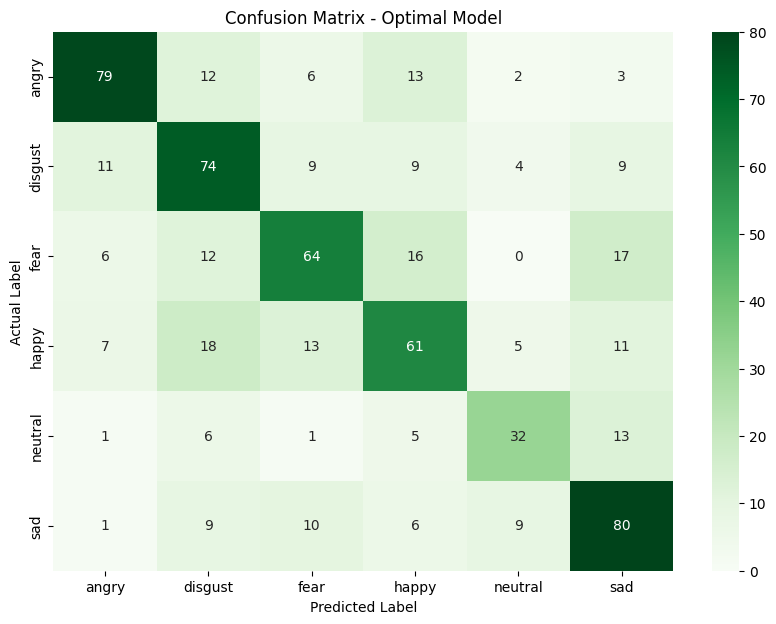

In [41]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import pandas as pd

# 1. Lấy dự đoán cho Baseline Model
y_pred_baseline_probs = model_baseline.predict(X_test)
y_pred_baseline_classes = np.argmax(y_pred_baseline_probs, axis=1)
y_true_classes = np.argmax(y_test, axis=1)

# 2. Lấy dự đoán cho Optimal Model
y_pred_optimal_probs = optimal_model.predict(X_test_aug)
y_pred_optimal_classes = np.argmax(y_pred_optimal_probs, axis=1)
y_true_classes_aug = np.argmax(y_test_aug, axis=1)

# Lấy tên các lớp cảm xúc
emotion_labels = le.classes_

# 3. Vẽ Confusion Matrix cho Baseline Model
cm_baseline = confusion_matrix(y_true_classes, y_pred_baseline_classes)
cm_baseline_df = pd.DataFrame(cm_baseline, index=emotion_labels, columns=emotion_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_baseline_df, annot=True, fmt='g', cmap='Blues')
plt.title('Confusion Matrix - Baseline Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

# 4. Vẽ Confusion Matrix cho Optimal Model
cm_optimal = confusion_matrix(y_true_classes_aug, y_pred_optimal_classes)
cm_optimal_df = pd.DataFrame(cm_optimal, index=emotion_labels, columns=emotion_labels)

plt.figure(figsize=(10, 7))
sns.heatmap(cm_optimal_df, annot=True, fmt='g', cmap='Greens')
plt.title('Confusion Matrix - Optimal Model')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

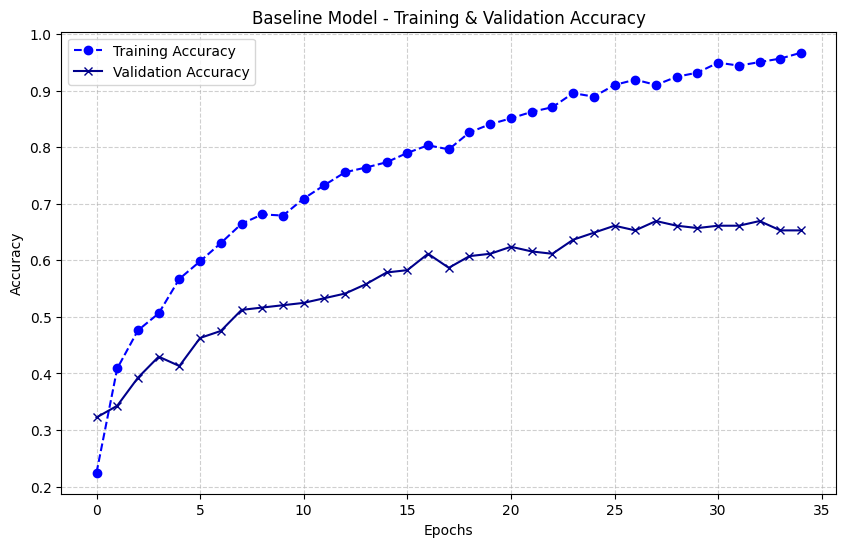

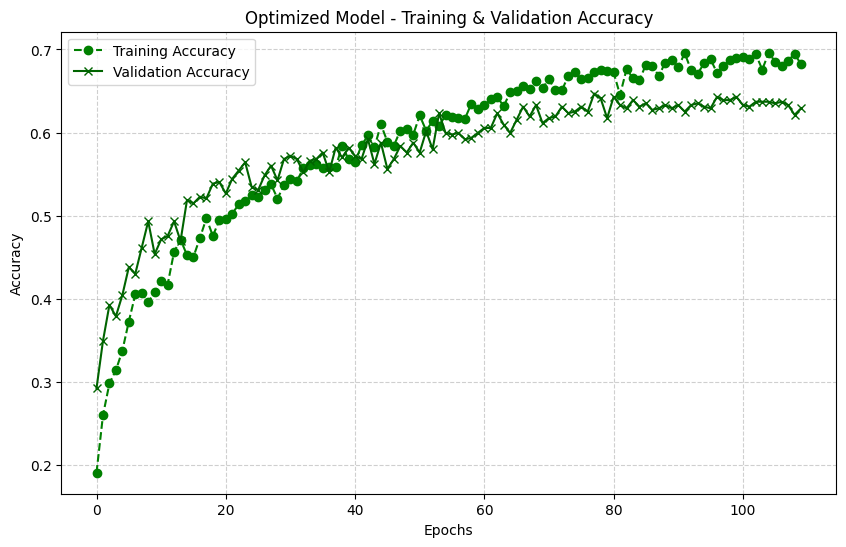

In [42]:
import matplotlib.pyplot as plt

# --- Đồ thị 1: Baseline Model ---

# Lấy history của model Baseline. Trong notebook của bạn, nó được lưu trong biến tên 'history'.
history_baseline = history 

# Trích xuất dữ liệu accuracy
acc_baseline = history_baseline.history['accuracy']
val_acc_baseline = history_baseline.history['val_accuracy']
epochs_range_baseline = range(len(acc_baseline))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(epochs_range_baseline, acc_baseline, label='Training Accuracy', color='blue', marker='o', linestyle='--')
plt.plot(epochs_range_baseline, val_acc_baseline, label='Validation Accuracy', color='darkblue', marker='x')
plt.title('Baseline Model - Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


# --- Đồ thị 2: Optimized Model ---

# Lấy history của model Tối ưu. Biến này đã được đặt tên là 'history_optimal'.
history_optimal = history_optimal

# Trích xuất dữ liệu accuracy
acc_optimal = history_optimal.history['accuracy']
val_acc_optimal = history_optimal.history['val_accuracy']
epochs_range_optimal = range(len(acc_optimal))

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
plt.plot(epochs_range_optimal, acc_optimal, label='Training Accuracy', color='green', marker='o', linestyle='--')
plt.plot(epochs_range_optimal, val_acc_optimal, label='Validation Accuracy', color='darkgreen', marker='x')
plt.title('Optimized Model - Training & Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()